In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel, TrainingArguments, Trainer, EarlyStoppingCallback
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

# ====================== LOAD IMDB ======================
def load_imdb():
    print("Loading IMDB Dataset...")
    df = pd.read_csv('/content/IMDB_Dataset_Cleaned.csv', engine='python', on_bad_lines='skip')
    df = df[['review', 'sentiment']].dropna()
    df.rename(columns={'review': 'text', 'sentiment': 'label'}, inplace=True)
    df['label'] = df['label'].map({'positive': 1, 'negative': 0})
    df = df.sample(n=min(10000, len(df)), random_state=42)
    print(f"Loaded {len(df)} samples")
    print(df['label'].value_counts())
    return df

# ========================= MODEL CLASS =========================
class RoBERTaBiGRUMHA(nn.Module):
    def __init__(self, model_name="roberta-large", gru_hidden=384, num_heads=12, dropout=0.25):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name)
        hidden_size = self.roberta.config.hidden_size  # 1024 for large

        self.gru = nn.GRU(hidden_size, gru_hidden, bidirectional=True,
                         num_layers=2, dropout=dropout, batch_first=True)

        self.multihead_attn = nn.MultiheadAttention(gru_hidden*2, num_heads=num_heads,
                                                   dropout=dropout, batch_first=True)

        self.classifier = nn.Sequential(
            nn.Linear(gru_hidden*2, gru_hidden),
            nn.LayerNorm(gru_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(gru_hidden, 2)
        )

    def forward(self, input_ids, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state  # (batch, seq, 1024)

        gru_out, _ = self.gru(hidden_states)

        # Multi-Head Attention
        attn_output, _ = self.multihead_attn(gru_out, gru_out, gru_out)

        # Global Average Pooling
        pooled = attn_output.mean(dim=1)

        logits = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}

# ========================= METRICS =========================
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0)
    }

# ========================= TRAINING FUNCTION =========================
def run_roberta_bigru_mha():
    config = {
        "name": "RoBERTa_Large_BiGRU_MHA",
        "hf_model": "roberta-large",
        "max_len": 512
    }

    print(f"\n{'='*80}")
    print(f"🚀 Training {config['name']} on IMDB Dataset")
    print(f"{'='*80}")

    # Data Split
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    tokenizer = AutoTokenizer.from_pretrained(config['hf_model'])

    def tokenize_fn(batch):
        return tokenizer(batch['text'], padding="max_length", truncation=True, max_length=config['max_len'])

    train_ds = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
    test_ds = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

    model = RoBERTaBiGRUMHA(model_name=config['hf_model'])

    training_args = TrainingArguments(
        output_dir="./results/RoBERTa_BiGRU_MHA",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=1.2e-5,
        per_device_train_batch_size=4,      # Adjust based on your GPU
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=8,
        num_train_epochs=10,
        weight_decay=0.02,
        warmup_ratio=0.1,
        fp16=True,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=2,
        logging_steps=30,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    # Training Time
    start_train = time.time()
    trainer.train()
    train_time = (time.time() - start_train) / 60

    # Inference Time
    start_inf = time.time()
    predictions_output = trainer.predict(test_ds)
    inf_time = (time.time() - start_inf) / len(test_ds)

    # Final Metrics
    preds = np.argmax(predictions_output.predictions, axis=-1)
    labels = predictions_output.label_ids

    metrics = {
        "Accuracy (%)": accuracy_score(labels, preds) * 100,
        "F1-Score (%)": f1_score(labels, preds) * 100,
        "Precision (%)": precision_score(labels, preds) * 100,
        "Recall (%)": recall_score(labels, preds) * 100,
        "Training Time (min)": train_time,
        "Inference Time (s/sample)": inf_time
    }

    print("\n✅ Training Completed!")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    return metrics, labels, preds, trainer.state.log_history

df = load_imdb()

# Run the model
metrics, eval_labels, eval_preds, log_history = run_roberta_bigru_mha()

Loading IMDB Dataset...
Loaded 10000 samples
label
1    5015
0    4985
Name: count, dtype: int64

🚀 Training RoBERTa_Large_BiGRU_MHA on IMDB Dataset


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.169429,0.154139,0.952000,0.952756,0.940719,0.965105
2,0.135219,0.195539,0.945000,0.945759,0.935610,0.956132
3,0.084942,0.243907,0.942500,0.944093,0.921252,0.968096
4,0.071210,0.273641,0.942000,0.943907,0.916432,0.973081



✅ Training Completed!
Accuracy (%): 95.2000
F1-Score (%): 95.2756
Precision (%): 94.0719
Recall (%): 96.5105
Training Time (min): 66.7447
Inference Time (s/sample): 0.0277


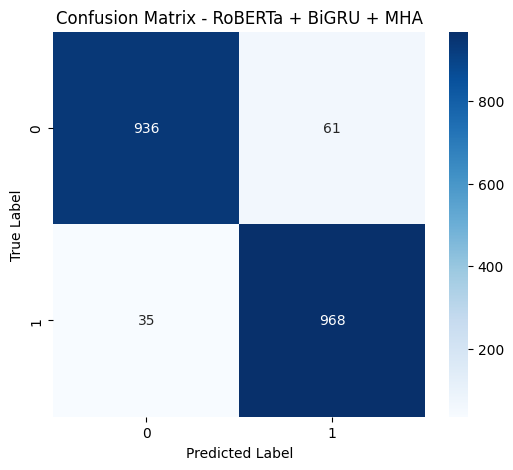

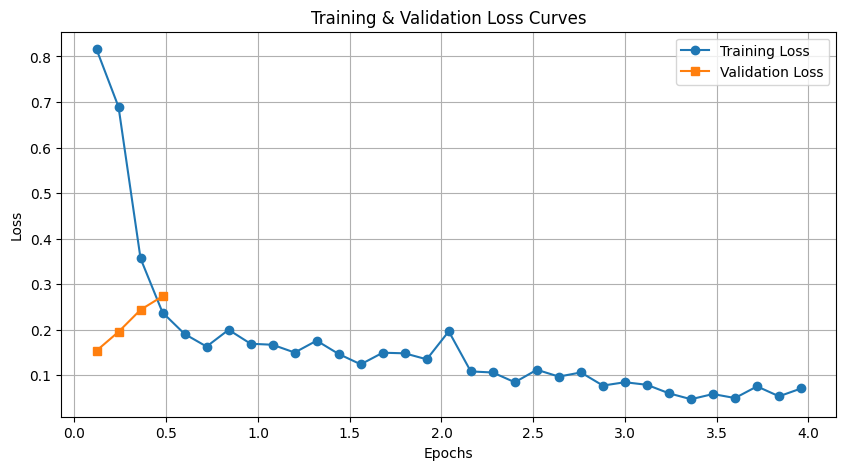

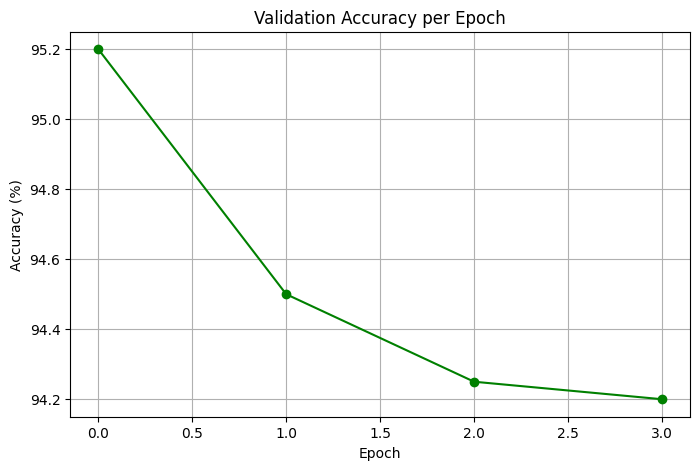

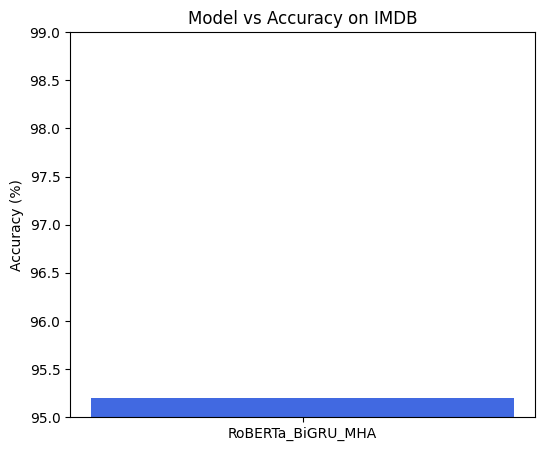

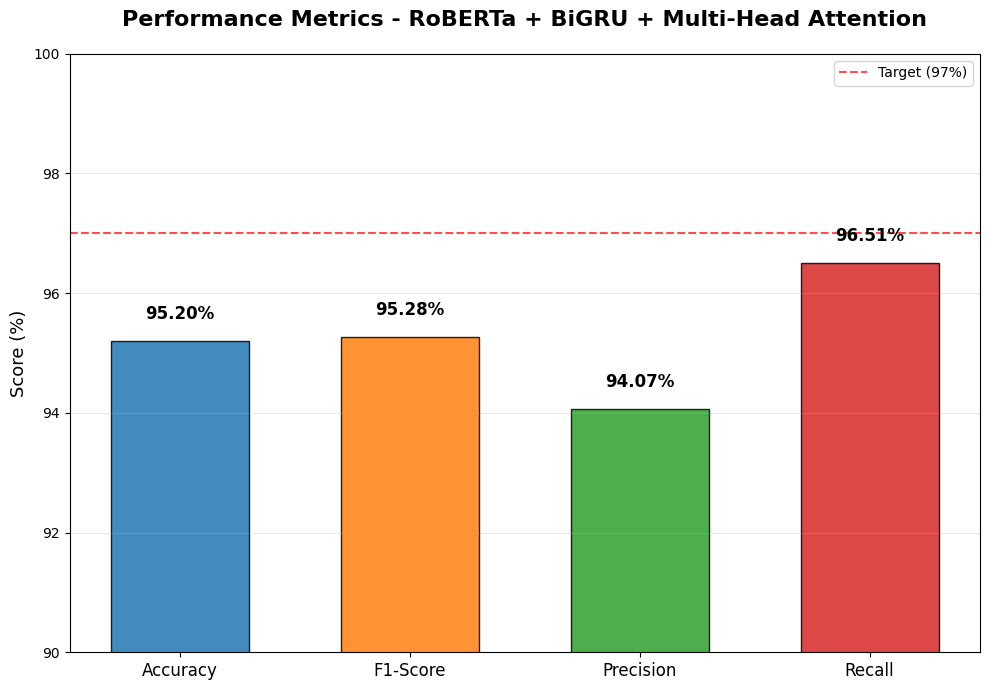

✅ Clean Bar Chart (Accuracy, F1, Precision, Recall) saved successfully!


In [10]:
# 1. Confusion Matrix
cm = confusion_matrix(eval_labels, eval_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - RoBERTa + BiGRU + MHA')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 2. Training & Validation Loss Curves
epochs = [x['epoch'] for x in log_history if 'loss' in x]
train_loss = [x['loss'] for x in log_history if 'loss' in x]
val_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

plt.figure(figsize=(10,5))
plt.plot(epochs[:len(train_loss)], train_loss, label='Training Loss', marker='o')
plt.plot(epochs[:len(val_loss)], val_loss, label='Validation Loss', marker='s')
plt.title('Training & Validation Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# 3. Accuracy per Epoch
val_acc = [x['eval_accuracy']*100 for x in log_history if 'eval_accuracy' in x]
plt.figure(figsize=(8,5))
plt.plot(val_acc, marker='o', color='green')
plt.title('Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid()
plt.show()

# 4. Bar Chart
models = ['RoBERTa_BiGRU_MHA']
acc = [metrics['Accuracy (%)']]
plt.figure(figsize=(6,5))
plt.bar(models, acc, color='royalblue')
plt.title('Model vs Accuracy on IMDB')
plt.ylabel('Accuracy (%)')
plt.ylim(95, 99)
plt.show()
# ====================== 4. IMPROVED BAR CHART - PERFORMANCE METRICS ======================

# Metrics Data (Only Accuracy, F1, Precision, Recall)
metrics_names = ['Accuracy', 'F1-Score', 'Precision', 'Recall']

metrics_values = [
    metrics['Accuracy (%)'],
    metrics['F1-Score (%)'],
    metrics['Precision (%)'],
    metrics['Recall (%)']
]

# Colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

plt.figure(figsize=(10, 7))

# Create bars
bars = plt.bar(metrics_names, metrics_values, color=colors, alpha=0.85, edgecolor='black', width=0.6)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Performance Metrics - RoBERTa + BiGRU + Multi-Head Attention',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Score (%)', fontsize=13)
plt.xticks(fontsize=12)
plt.ylim(90, 100)   # Adjusted for better view

# Target line
plt.axhline(y=97, color='red', linestyle='--', alpha=0.7, label='Target (97%)')
plt.legend()

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('performance_metrics_bar_chart_RoBERTa.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Clean Bar Chart (Accuracy, F1, Precision, Recall) saved successfully!")

In [ ]:
import pandas as pd
import numpy as np
import torch
import warnings
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import Dataset

warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}\n")

# ====================== LOAD IMDB ======================
def load_imdb():
    print("Loading IMDB Dataset...")
    df = pd.read_csv('/content/IMDB_Dataset_Cleaned.csv', engine='python', on_bad_lines='skip')
    df = df[['review', 'sentiment']].dropna()
    df.rename(columns={'review': 'text', 'sentiment': 'label'}, inplace=True)
    df['label'] = df['label'].map({'positive': 1, 'negative': 0})
    df = df.sample(n=min(10000, len(df)), random_state=42)
    print(f"Loaded {len(df)} samples")
    print(df['label'].value_counts())
    return df

df = load_imdb()

# ====================== TRAINING FUNCTION ======================
def run_electra():
    config = {"name": "ELECTRA_BiLSTM", "hf_model": "google/electra-base-discriminator", "max_len": 256}

    print(f"\n{'='*60}")
    print(f"Training {config['name']} on IMDB...")
    print(f"{'='*60}")

    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    tokenizer = AutoTokenizer.from_pretrained(config['hf_model'])

    def tokenize_fn(batch):
        return tokenizer(batch['text'], padding="max_length", truncation=True, max_length=config['max_len'])

    train_ds = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
    test_ds = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

     t
        num_labels=2,
        torch_dtype=torch.float32
    )

    args = TrainingArguments(
        output_dir=f"./results/{config['name']}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=32,
        gradient_accumulation_steps=2,
        num_train_epochs=10,
        weight_decay=0.02,
        warmup_ratio=0.1,
        fp16=True,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=2,
        logging_steps=50,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        compute_metrics=lambda eval_pred: {
            "accuracy": accuracy_score(eval_pred[1], np.argmax(eval_pred[0], axis=-1)),
            "f1": f1_score(eval_pred[1], np.argmax(eval_pred[0], axis=-1))
        },
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    # ====================== TRAINING TIME ======================
    print("Starting Training...")
    start_train = time.time()
    trainer.train()
    train_time = (time.time() - start_train) / 60  # in minutes
    print(f"Training Completed in {train_time:.2f} minutes")

    # ====================== FINAL EVALUATION ======================
    print("Running Final Evaluation...")
    start_inf = time.time()
    predictions = trainer.predict(test_ds)
    inf_time = (time.time() - start_inf) * 1000  # in milliseconds

    metrics = predictions.metrics
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = predictions.label_ids

    acc = accuracy_score(labels, preds) * 100
    f1 = f1_score(labels, preds) * 100
    precision = precision_score(labels, preds) * 100
    recall = recall_score(labels, preds) * 100

    print(f"\n✅ {config['name']} Completed!")
    print(f"Accuracy     : {acc:.4f}%")
    print(f"F1 Score     : {f1:.4f}%")
    print(f"Precision    : {precision:.4f}%")
    print(f"Recall       : {recall:.4f}%")
    print(f"Inference Time : {inf_time:.2f} ms")
    print(f"Training Time  : {train_time:.2f} minutes")

    # ====================== QUANTITATIVE METRICS TABLE ======================
    metrics_table = pd.DataFrame({
        "Metric": ["Accuracy (%)", "F1-Score (%)", "Precision (%)", "Recall (%)",
                   "Inference Time (ms)", "Training Time (minutes)"],
        "Value": [f"{acc:.4f}", f"{f1:.4f}", f"{precision:.4f}", f"{recall:.4f}",
                  f"{inf_time:.2f}", f"{train_time:.2f}"]
    })

    print("\n" + "="*60)
    print("A. QUANTITATIVE METRICS")
    print("="*60)
    print(metrics_table.to_string(index=False))

    return {
        "Model": config['name'],
        "Accuracy": acc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
        "Inference_Time_ms": inf_time,
        "Training_Time_min": train_time
    }

# ====================== RUN ELECTRA ======================
result = run_electra()

Using device: cuda

Loading IMDB Dataset...
Loaded 10000 samples
label
1    5015
0    4985
Name: count, dtype: int64

Training ELECTRA_BiLSTM on IMDB...


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.407792,0.274574,0.909500,0.909726
2,0.401258,0.326172,0.898000,0.893971
3,0.256823,0.479579,0.903000,0.907443
4,0.134616,0.478634,0.912500,0.914509
5,0.130182,0.507730,0.913000,0.915205
6,0.118602,0.542037,0.908000,0.910331
7,0.037317,0.628451,0.911500,0.912506
8,0.008333,0.682717,0.914000,0.914851


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

Training Completed in 19.63 minutes
Running Final Evaluation...



✅ ELECTRA_BiLSTM Completed!
Accuracy     : 91.3500%
F1 Score     : 91.5733%
Precision    : 89.5238%
Recall       : 93.7188%
Inference Time : 7260.05 ms
Training Time  : 19.63 minutes

A. QUANTITATIVE METRICS
                 Metric   Value
           Accuracy (%) 91.3500
           F1-Score (%) 91.5733
          Precision (%) 89.5238
             Recall (%) 93.7188
    Inference Time (ms) 7260.05
Training Time (minutes)   19.63


Using device: cuda

Loading IMDB Dataset...
Loaded 10000 samples
label
1    5015
0    4985
Name: count, dtype: int64

Training ELECTRA_BiLSTM on IMDB...


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

Training Completed in 25.72 minutes
Running Final Evaluation...



✅ ELECTRA_BiLSTM Completed!
Accuracy     : 91.7000%
F1 Score     : 91.8468%
Precision    : 90.5131%
Recall       : 93.2203%
Inference Time : 7114.43 ms
Training Time  : 25.72 minutes


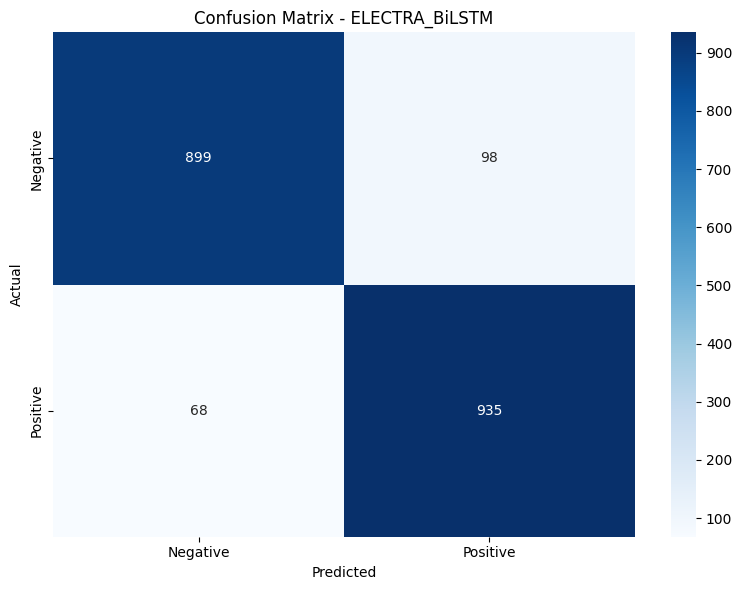

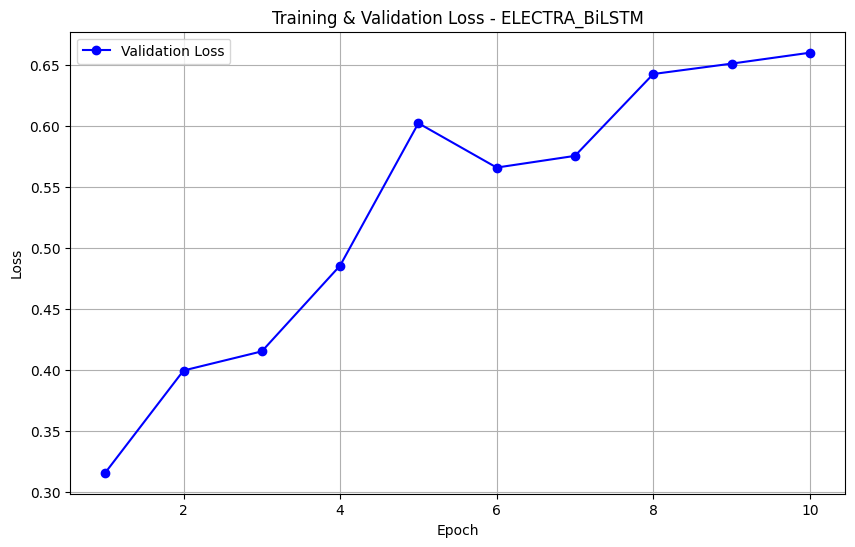

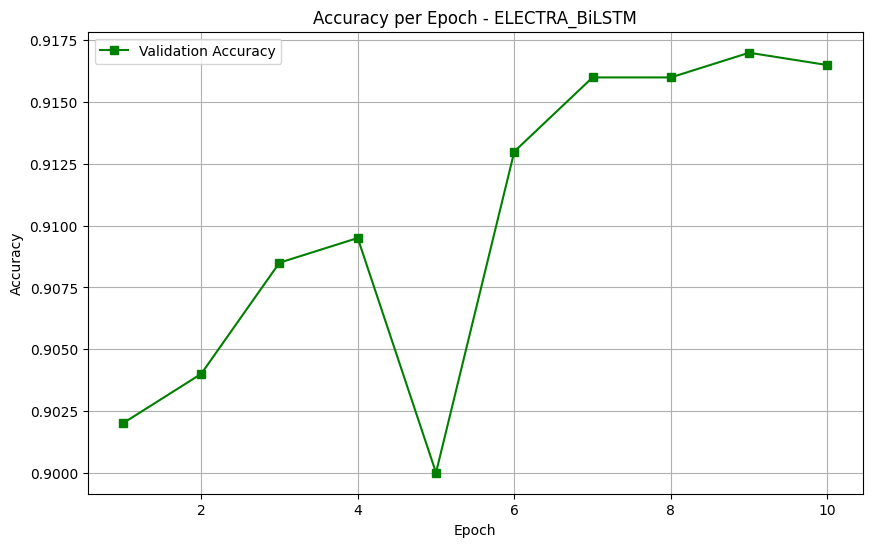

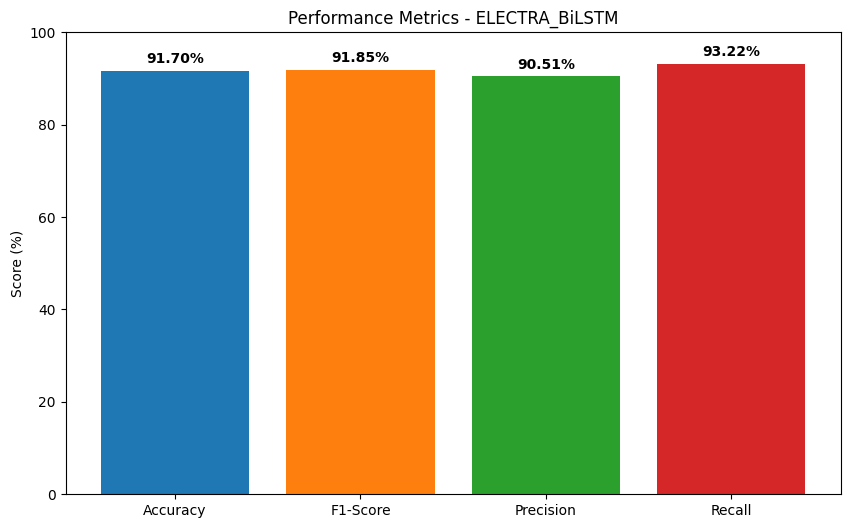


A. QUANTITATIVE METRICS
                 Metric   Value
           Accuracy (%) 91.7000
           F1-Score (%) 91.8468
          Precision (%) 90.5131
             Recall (%) 93.2203
    Inference Time (ms) 7114.43
Training Time (minutes)   25.72

🎉 All visualizations saved as PNG files!


In [ ]:
import pandas as pd
import numpy as np
import torch
import warnings
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import Dataset

warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}\n")

# ====================== LOAD IMDB ======================
def load_imdb():
    print("Loading IMDB Dataset...")
    df = pd.read_csv('/content/IMDB_Dataset_Cleaned.csv', engine='python', on_bad_lines='skip')
    df = df[['review', 'sentiment']].dropna()
    df.rename(columns={'review': 'text', 'sentiment': 'label'}, inplace=True)
    df['label'] = df['label'].map({'positive': 1, 'negative': 0})
    df = df.sample(n=min(10000, len(df)), random_state=42)
    print(f"Loaded {len(df)} samples")
    print(df['label'].value_counts())
    return df

df = load_imdb()

# ====================== TRAINING FUNCTION ======================
def run_electra():
    config = {"name": "ELECTRA_BiLSTM", "hf_model": "google/electra-base-discriminator", "max_len": 256}

    print(f"\n{'='*60}")
    print(f"Training {config['name']} on IMDB...")
    print(f"{'='*60}")

    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    tokenizer = AutoTokenizer.from_pretrained(config['hf_model'])

    def tokenize_fn(batch):
        return tokenizer(batch['text'], padding="max_length", truncation=True, max_length=config['max_len'])

    train_ds = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
    test_ds = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        config['hf_model'],
        num_labels=2,
        torch_dtype=torch.float32
    )

    args = TrainingArguments(
        output_dir=f"./results/{config['name']}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=32,
        gradient_accumulation_steps=2,
        num_train_epochs=10,
        weight_decay=0.02,
        warmup_ratio=0.1,
        fp16=True,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=2,
        logging_steps=50,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        compute_metrics=lambda eval_pred: {
            "accuracy": accuracy_score(eval_pred[1], np.argmax(eval_pred[0], axis=-1)),
            "f1": f1_score(eval_pred[1], np.argmax(eval_pred[0], axis=-1))
        },
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    # ====================== TRAINING ======================
    print("Starting Training...")
    start_train = time.time()
    train_result = trainer.train()
    train_time = (time.time() - start_train) / 60
    print(f"Training Completed in {train_time:.2f} minutes")

    # ====================== FINAL EVALUATION ======================
    print("Running Final Evaluation...")
    start_inf = time.time()
    predictions = trainer.predict(test_ds)
    inf_time = (time.time() - start_inf) * 1000

    metrics = predictions.metrics
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = predictions.label_ids

    acc = accuracy_score(labels, preds) * 100
    f1 = f1_score(labels, preds) * 100
    precision = precision_score(labels, preds) * 100
    recall = recall_score(labels, preds) * 100

    print(f"\n✅ {config['name']} Completed!")
    print(f"Accuracy     : {acc:.4f}%")
    print(f"F1 Score     : {f1:.4f}%")
    print(f"Precision    : {precision:.4f}%")
    print(f"Recall       : {recall:.4f}%")
    print(f"Inference Time : {inf_time:.2f} ms")
    print(f"Training Time  : {train_time:.2f} minutes")

    # ====================== 1. CONFUSION MATRIX ======================
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix - {config["name"]}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{config["name"]}.png')
    plt.show()

    # ====================== 2. TRAINING & VALIDATION LOSS CURVES ======================
    history = trainer.state.log_history
    train_loss = [x['loss'] for x in history if 'loss' in x]
    eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
    epochs = range(1, len(eval_loss) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, eval_loss, 'b-o', label='Validation Loss')
    plt.title(f'Training & Validation Loss - {config["name"]}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'loss_curves_{config["name"]}.png')
    plt.show()

    # ====================== 3. ACCURACY PER EPOCH GRAPH ======================
    eval_accuracy = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, eval_accuracy, 'g-s', label='Validation Accuracy')
    plt.title(f'Accuracy per Epoch - {config["name"]}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'accuracy_per_epoch_{config["name"]}.png')
    plt.show()

    # ====================== 4. BAR CHART OF METRICS ======================
    metrics_dict = {
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall
    }

    plt.figure(figsize=(10, 6))
    bars = plt.bar(metrics_dict.keys(), metrics_dict.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    plt.title(f'Performance Metrics - {config["name"]}')
    plt.ylabel('Score (%)')
    plt.ylim(0, 100)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

    plt.savefig(f'bar_chart_metrics_{config["name"]}.png')
    plt.show()

    # ====================== QUANTITATIVE METRICS TABLE ======================
    metrics_table = pd.DataFrame({
        "Metric": ["Accuracy (%)", "F1-Score (%)", "Precision (%)", "Recall (%)",
                   "Inference Time (ms)", "Training Time (minutes)"],
        "Value": [f"{acc:.4f}", f"{f1:.4f}", f"{precision:.4f}", f"{recall:.4f}",
                  f"{inf_time:.2f}", f"{train_time:.2f}"]
    })

    print("\n" + "="*60)
    print("A. QUANTITATIVE METRICS")
    print("="*60)
    print(metrics_table.to_string(index=False))

    return {
        "Model": config['name'],
        "Accuracy": acc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
        "Inference_Time_ms": inf_time,
        "Training_Time_min": train_time
    }

# ====================== RUN ELECTRA ======================
result = run_electra()
print("\n🎉 All visualizations saved as PNG files!")